# Z-Component Histogram Ratio Demo
This notebook demonstrates the z-component histograms and their ratios (each divided by the sum of the two) for Central Spin Hamiltonians with **uniform**, **Gaussian**, and **Lorentzian** disorder.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import disentanglement as dis
import sys
import os

# Add current directory to path if needed (for local imports)
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

In [2]:
# System Parameters
N_star = 10  # Number of bath spins
Jx_base = 0.
Jz_base = 0.
seed = 42
time_t = 0.1  # Time for evolution
disorder_strength = 10. / N_star

print(f"System: N_star={N_star}, Jx={Jx_base}, Jz={Jz_base}, Seed={seed}")
print(f"Disorder strength: {disorder_strength}")
print(f"Evolution time: {time_t}")

System: N_star=10, Jx=0.0, Jz=0.0, Seed=42
Disorder strength: 1.0
Evolution time: 0.1


## Helper: run analysis for a given disorder type
Generates the Hamiltonian, computes the time-evolution operator, performs the disentanglement analysis, and plots both the raw z-component histograms and the ratio plot.

In [3]:
def run_analysis(disorder_type, N_star, Jx, Jz, disorder_strength, time_t, seed, bins=30):
    """Run disentanglement analysis and plot histograms + ratio for a given disorder type."""
    print(f"\n{'='*60}")
    print(f"  Disorder type: {disorder_type}")
    print(f"{'='*60}")

    gen = dis.CentralSpinHamiltonianQuSpin(
        N_star=N_star,
        Jx=Jx, Jz=Jz,
        disorder_type=disorder_type,
        disorder_strength=disorder_strength,
        seed=seed
    )
    H_mat = gen.generate()

    U = expm(-1j * H_mat * time_t)

    analyzer = dis.DisentanglementAnalyzer(U)
    analyzer.get_initial_qubit_states_from_eigenvalues()

    visualizer = dis.DisentanglementVisualizer(analyzer)

    # Plot raw z-component histograms
    visualizer.plot_z_histograms()
    plt.suptitle(f"Z-component histograms — {disorder_type} disorder", y=1.02)
    plt.show()

    # Plot ratio histograms
    visualizer.plot_z_histograms_ratio(bins=bins)
    plt.suptitle(f"Z-component histogram ratios — {disorder_type} disorder", y=1.02)
    plt.show()

## 1. Uniform Disorder


  Disorder type: uniform


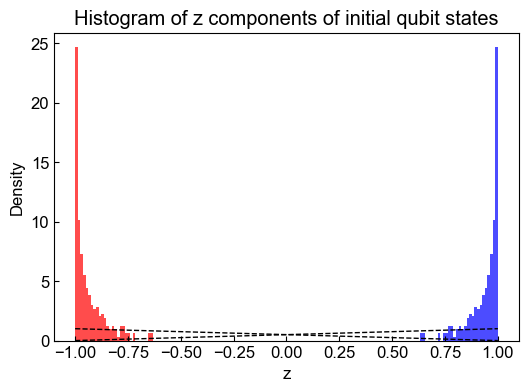

<Figure size 640x480 with 0 Axes>

c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\disentanglement.py:597: RuntimeWarning: invalid value encountered in divide
  ratio0 = np.where(mask, h0 / h_sum, 0)
c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\disentanglement.py:598: RuntimeWarning: invalid value encountered in divide
  ratio1 = np.where(mask, h1 / h_sum, 0)


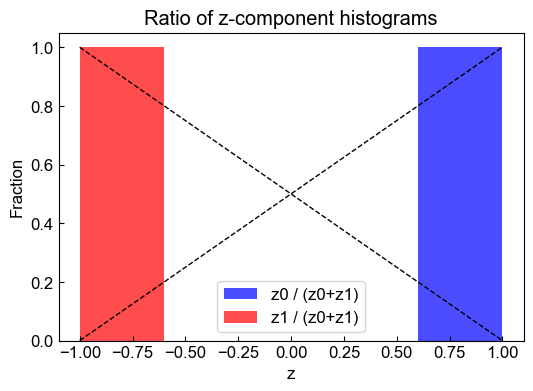

<Figure size 640x480 with 0 Axes>

In [4]:
run_analysis("uniform", N_star, Jx_base, Jz_base, disorder_strength, time_t, seed)

## 2. Gaussian Disorder


  Disorder type: gaussian


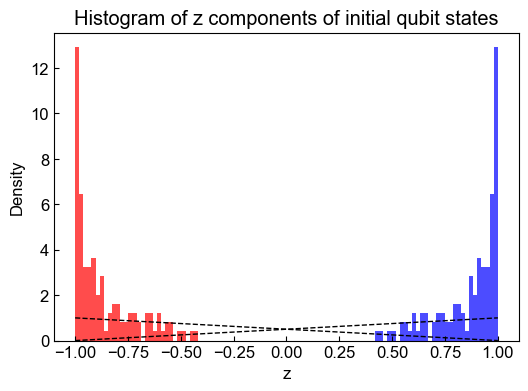

<Figure size 640x480 with 0 Axes>

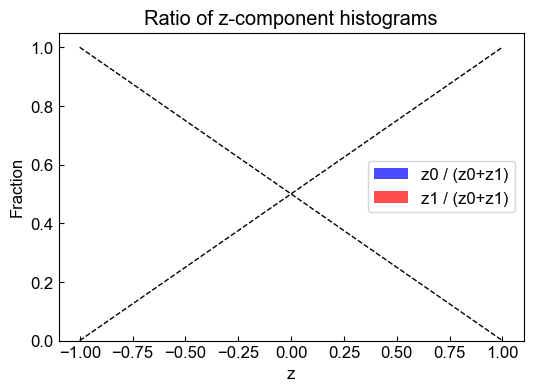

<Figure size 640x480 with 0 Axes>

In [5]:
run_analysis("gaussian", N_star, Jx_base, Jz_base, disorder_strength, time_t, seed)

## 3. Lorentzian Disorder


  Disorder type: lorentzian


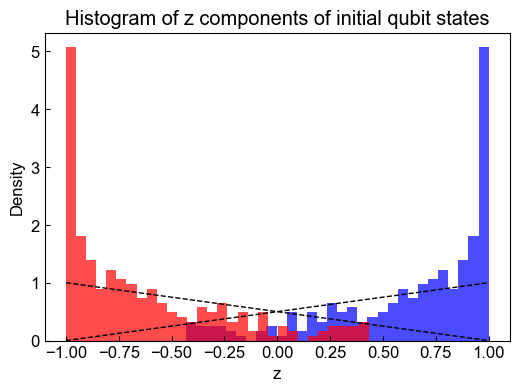

<Figure size 640x480 with 0 Axes>

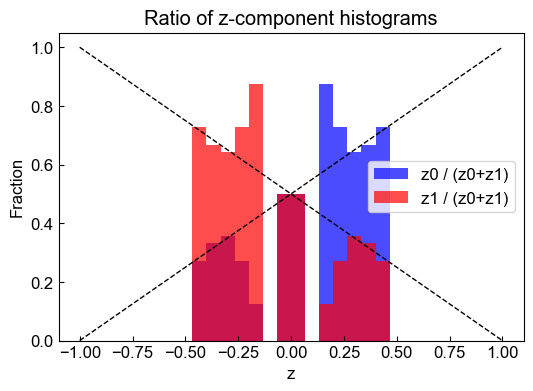

<Figure size 640x480 with 0 Axes>

In [48]:
N_star = 10  # Number of environment spins
run_analysis(
    "lorentzian",
    N_star=N_star,
    Jx=0.0,
    Jz=0.0,
    disorder_strength=0.5 / N_star,
    time_t=1.0,
    bins=30,
    seed=seed
)